# 📊 DeepLOB — Model Testing & Results Dashboard

**What this notebook does, in one sentence:** it loads your trained DeepLOB model, runs it on test days it has never seen, *trades* on its predictions, and shows you — visually — whether the model is any good and whether the strategy makes money.

You do **not** need to know the internals. Read top to bottom. Every section has a plain‑English explanation above the chart, and a one‑line takeaway below it.

---

### The 4 questions this notebook answers

| # | Question | Where |
|---|----------|-------|
| 1 | Is the model *accurate*? (does it guess direction right) | §3 Hits & Misses |
| 2 | Is the model *confident when it's right*? | §4 Confidence |
| 3 | Does trading on it *make money*? | §5 P&L & Equity |
| 4 | *How* did it trade — what did it actually do each day? | §6 Trade Blotter |

> **Glossary (read once):**
> **Window** = one decision point (the model looks at the last 100 order‑book snapshots). •
> **Edge** = model's directional conviction, from −1 (sure down) to +1 (sure up). •
> **Hit** = predicted direction matched what actually happened. •
> **Fill** = a single trade action (open/add/trim/close). •
> **EOD** = end of day; the book is always flattened (no overnight risk).


## 1. Setup

This cell finds your project folders automatically. The notebook expects to sit in the **root**, beside `DeepLOB/`, `ETL/`, `backtester/`, and `tensors/`. If something isn't found, the message tells you exactly what to fix.

In [21]:
import os, sys, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})
# Colorblind-friendly palette
C = {"up":"#1b9e77", "down":"#d95f02", "flat":"#7570b3",
     "win":"#1b9e77", "loss":"#d95f02", "equity":"#2166ac", "accent":"#e6550d"}

ROOT = os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "backtest"))
import backtest.backtester as B

print("Project root :", ROOT)
print("Tensors dir  :", B.CONFIG["base_dir"], "✓" if os.path.isdir(B.CONFIG["base_dir"]) else "✗ NOT FOUND")
print("Checkpoint   :", B.CONFIG["checkpoint"], "✓" if os.path.exists(B.CONFIG["checkpoint"]) else "✗ NOT FOUND")
print("DeepLOB model:", "✓ imported" if B.DeepLOB is not None else "✗ import failed")

Project root : /home/ash/Desktop/kairos/code/brain/src
Tensors dir  : /home/ash/Desktop/kairos/code/brain/src/tensors ✓
Checkpoint   : /home/ash/Desktop/kairos/code/brain/src/DeepLOB/best_deeplob_model.pth ✓
DeepLOB model: ✓ imported


## 2. Choose what to test

Edit the three values below if you want. The defaults use the **last 5 days** of data and your best saved model. Then we load the model.

In [22]:
# ---- EDIT THESE IF YOU LIKE ----
TICKERS   = ["AAPL", "SPY", "NVDA"]   # which symbols to test
TEST_DAYS = 10                          # how many most-recent days (ignored if TEST_DATES set)
TEST_DATES = None                      # or pin specific days, e.g. ["2024-09-30", "2024-10-01"]
KELLY_MULT = 0.5                       # position aggressiveness (0.5 = half-Kelly)
# --------------------------------

B.CONFIG.update({"tickers": TICKERS, "test_days": TEST_DAYS, "test_dates": TEST_DATES,
                 "device": "cuda" if torch.cuda.is_available() else "cpu",
                 "kelly_multiplier": KELLY_MULT})

DEVICE = B.CONFIG["device"]
model = B.DeepLOB(num_horizons=3).to(DEVICE)
model.load_state_dict(torch.load(B.CONFIG["checkpoint"], map_location=DEVICE, weights_only=True))
model.eval()

DATES = B.discover_test_dates(B.CONFIG["base_dir"], TICKERS, TEST_DAYS, TEST_DATES)
HZ = B.HORIZONS  # [10, 20, 50]
print(f"Device: {DEVICE}")
print(f"Testing {len(TICKERS)} tickers over {len(DATES)} days: {DATES}")
print(f"Prediction horizons: {HZ}  (we headline the longest, h{HZ[-1]}, as the paper recommends)")

Device: cuda
Testing 3 tickers over 10 days: ['2024-09-23', '2024-09-24', '2024-09-25', '2024-09-27', '2024-09-30', '2024-11-04', '2024-11-05', '2024-11-18', '2024-12-23', '2025-04-02']
Prediction horizons: [10, 20, 50]  (we headline the longest, h50, as the paper recommends)


### Gather the model's predictions for every window

We loop over each ticker/day, run the model, and collect — per decision window — the predicted class, the true label, the confidence, and the signed edge. This is the raw material for everything below. (Runs once; cached in `pred_df`.)

In [23]:
BATCH_SIZE = 256   # fits comfortably in 8GB VRAM

HZ_LABELS = {0: "flat", 1: "up", 2: "down"}

def gather_predictions(model, dates, tickers, device, batch_size=BATCH_SIZE):
    """Collect per-window predictions. Batched to avoid GPU OOM."""
    all_dfs = []
    for day in dates:
        for tic in tickers:
            base = B.CONFIG["base_dir"]
            xp = os.path.join(base, tic, f"{tic}_{day}_X.pt")
            yp = os.path.join(base, tic, f"{tic}_{day}_Y.pt")
            if not (os.path.exists(xp) and os.path.exists(yp)):
                continue
            X = torch.load(xp, weights_only=True)
            Y = torch.load(yp, weights_only=True).numpy()
            n = len(X)

            # ---- Batched inference (prevents OOM on 8GB GPUs) ----
            prob_chunks = []
            for start in range(0, n, batch_size):
                xb = X[start:start+batch_size].to(device)
                with torch.no_grad():
                    prob_chunks.append(F.softmax(model(xb), dim=2).cpu().numpy())
                if device != "cpu":
                    torch.cuda.empty_cache()
            probs = np.concatenate(prob_chunks, axis=0)   # (N, 3, 3)

            # ---- Vectorized (no per-row loop) ----
            for h_idx, h in enumerate(HZ):
                pred_cls = probs[:, h_idx, :].argmax(1)
                conf = probs[:, h_idx, :].max(1)
                edge = probs[:, h_idx, 1] - probs[:, h_idx, 2]
                df = pd.DataFrame({
                    "day": day, "ticker": tic, "horizon": h,
                    "window": np.arange(n),
                    "pred": pred_cls.astype(int),
                    "true": Y[:, h_idx].astype(int),
                    "conf": conf.astype(float),
                    "edge": edge.astype(float),
                    "hit": pred_cls == Y[:, h_idx],
                })
                all_dfs.append(df)
            print(f"  {tic} {day}: {n:,} windows processed", flush=True)
    pred_df = pd.concat(all_dfs, ignore_index=True)
    return pred_df

pred_df = gather_predictions(model, DATES, TICKERS, DEVICE)
print(f"\nCollected {len(pred_df):,} prediction records "
      f"({pred_df['window'].nunique():,} windows × {len(TICKERS)} tickers × {len(HZ)} horizons)")
pred_df.head()

  AAPL 2024-09-23: 13,122 windows processed
  SPY 2024-09-23: 12,351 windows processed
  AAPL 2024-09-24: 14,324 windows processed
  SPY 2024-09-24: 10,806 windows processed
  AAPL 2024-09-25: 13,871 windows processed
  SPY 2024-09-25: 10,349 windows processed
  NVDA 2024-09-25: 29,463 windows processed
  AAPL 2024-09-27: 13,296 windows processed
  SPY 2024-09-27: 13,691 windows processed
  AAPL 2024-09-30: 12,297 windows processed
  SPY 2024-09-30: 12,880 windows processed
  NVDA 2024-09-30: 25,899 windows processed
  AAPL 2024-11-04: 15,398 windows processed
  SPY 2024-11-04: 16,693 windows processed
  NVDA 2024-11-04: 37,721 windows processed
  AAPL 2024-11-05: 16,048 windows processed
  SPY 2024-11-05: 14,575 windows processed
  AAPL 2024-11-18: 5,485 windows processed
  SPY 2024-11-18: 11,541 windows processed
  NVDA 2024-11-18: 36,432 windows processed
  AAPL 2024-12-23: 6,601 windows processed
  SPY 2024-12-23: 4,786 windows processed
  AAPL 2025-04-02: 9,796 windows processed
 

,day,ticker,horizon,window,pred,true,conf,edge,hit
0,2024-09-23,AAPL,10,0,2,2,0.937926,-0.911516,True
1,2024-09-23,AAPL,10,1,2,2,0.937926,-0.911516,True
2,2024-09-23,AAPL,10,2,2,2,0.937926,-0.911516,True
3,2024-09-23,AAPL,10,3,2,2,0.937926,-0.911516,True
4,2024-09-23,AAPL,10,4,2,2,0.937926,-0.911516,True


## 3. Is the model accurate? — Hits & Misses 🎯

A **hit** = the model predicted the right direction (up / down / flat). With 3 balanced classes, **random guessing scores ~33%**. Anything clearly above that line is real skill.

We show accuracy per horizon, then break it down by class so you can see *which* calls the model is good at.

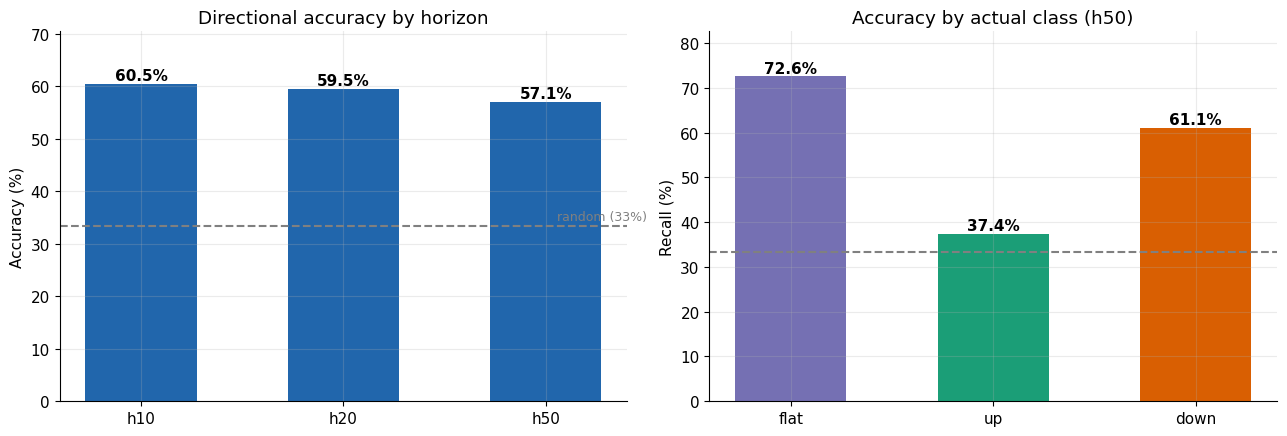

➤ TAKEAWAY: best horizon is h10 at 60.5% (above the 33% random line).


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: overall accuracy per horizon ---
acc = pred_df.groupby("horizon")["hit"].mean()
bars = axes[0].bar([f"h{h}" for h in acc.index], acc.values*100,
                   color=C["equity"], width=0.55)
axes[0].axhline(33.3, ls="--", color="grey", lw=1.5)
axes[0].text(len(acc)-0.5, 34.5, "random (33%)", color="grey", ha="right", fontsize=9)
axes[0].set_ylabel("Accuracy (%)"); axes[0].set_title("Directional accuracy by horizon")
axes[0].set_ylim(0, max(60, acc.max()*100+10))
for b, v in zip(bars, acc.values):
    axes[0].text(b.get_x()+b.get_width()/2, v*100+0.8, f"{v*100:.1f}%", ha="center", fontweight="bold")

# --- Right: per-class accuracy at headline horizon ---
h = HZ[-1]
sub = pred_df[pred_df.horizon==h]
per_class = sub.groupby("true")["hit"].mean()
names = [HZ_LABELS[c] for c in per_class.index]
cols = [C[HZ_LABELS[c]] for c in per_class.index]
axes[1].bar(names, per_class.values*100, color=cols, width=0.55)
axes[1].axhline(33.3, ls="--", color="grey", lw=1.5)
axes[1].set_ylabel("Recall (%)"); axes[1].set_title(f"Accuracy by actual class (h{h})")
axes[1].set_ylim(0, max(60, per_class.max()*100+10))
for i, v in enumerate(per_class.values):
    axes[1].text(i, v*100+0.8, f"{v*100:.1f}%", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

best_h = acc.idxmax()
print(f"➤ TAKEAWAY: best horizon is h{best_h} at {acc.max()*100:.1f}% "
      f"({'above' if acc.max()>0.333 else 'at/below'} the 33% random line).")

### Where exactly does it go right and wrong? — Confusion matrix

Rows = what actually happened. Columns = what the model predicted. The **diagonal is hits**; everything off‑diagonal is a miss. The worst mistakes are the corners (predicting *up* when it went *down*, or vice‑versa) — those cost the most money.

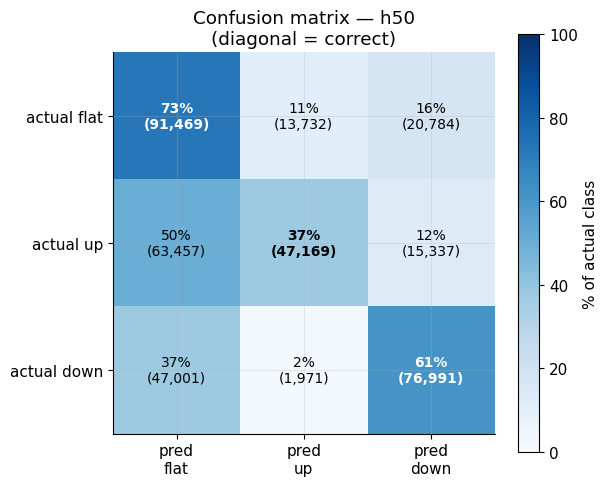

➤ TAKEAWAY: 215,629 correct of 377,911. Costly reversals (up↔down confusion): 17,308 (4.6% of all calls).


In [25]:
from itertools import product
h = HZ[-1]
sub = pred_df[pred_df.horizon==h]
labels = [0,1,2]; lab_names=["flat","up","down"]
cm = np.zeros((3,3), dtype=int)
for t,p in zip(sub["true"], sub["pred"]):
    cm[t,p]+=1
cm_pct = cm / cm.sum(1, keepdims=True).clip(min=1) * 100

fig, ax = plt.subplots(figsize=(6.2,5.2))
im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(3)); ax.set_xticklabels([f"pred\n{n}" for n in lab_names])
ax.set_yticks(range(3)); ax.set_yticklabels([f"actual {n}" for n in lab_names])
for i,j in product(range(3),range(3)):
    txt = f"{cm_pct[i,j]:.0f}%\n({cm[i,j]:,})"
    ax.text(j,i,txt,ha="center",va="center",
            color="white" if cm_pct[i,j]>55 else "black", fontsize=10,
            fontweight="bold" if i==j else "normal")
ax.set_title(f"Confusion matrix — h{h}\n(diagonal = correct)")
plt.colorbar(im, label="% of actual class"); plt.tight_layout(); plt.show()

corner = cm[1,2]+cm[2,1]
print(f"➤ TAKEAWAY: {cm.trace():,} correct of {cm.sum():,}. "
      f"Costly reversals (up↔down confusion): {corner:,} "
      f"({corner/cm.sum()*100:.1f}% of all calls).")

## 4. Is the model confident when it's right? 🔍

A good model isn't just accurate — it's **more accurate when it's more confident**. If accuracy rises with confidence, you can safely trade harder on high‑confidence signals (that's what the Kelly sizer does). If it's flat, confidence is meaningless and you shouldn't lean on it.

Left: how accuracy changes as confidence rises. Right: are confident calls actually more common when correct?

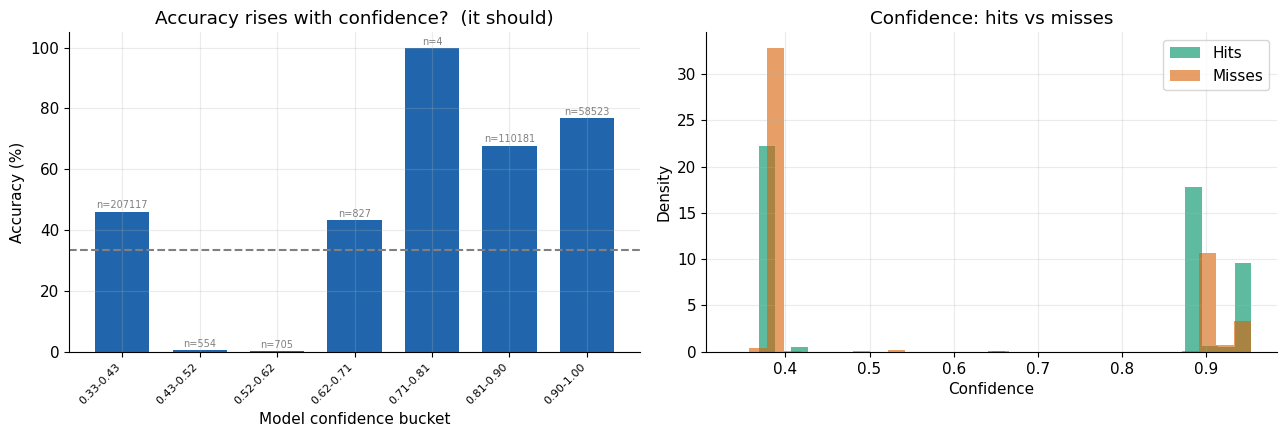

➤ TAKEAWAY: confidence↔correctness correlation = +0.255. Positive → trust confidence, size up on it.


In [26]:
h = HZ[-1]
sub = pred_df[pred_df.horizon==h].copy()

fig, axes = plt.subplots(1,2, figsize=(13,4.5))

# --- Left: accuracy vs confidence bucket (reliability) ---
sub["conf_bin"] = pd.cut(sub["conf"], bins=np.linspace(0.33,1.0,8))
rel = sub.groupby("conf_bin")["hit"].agg(["mean","count"])
xs = range(len(rel))
axes[0].bar(xs, rel["mean"]*100, color=C["equity"], width=0.7)
axes[0].axhline(33.3, ls="--", color="grey")
axes[0].set_xticks(list(xs))
axes[0].set_xticklabels([f"{iv.left:.2f}-{iv.right:.2f}" for iv in rel.index],
                        rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Accuracy (%)"); axes[0].set_xlabel("Model confidence bucket")
axes[0].set_title("Accuracy rises with confidence?  (it should)")
for x,(m,n) in zip(xs, rel.values):
    if n>0: axes[0].text(x, m*100+1, f"n={int(n)}", ha="center", fontsize=7, color="grey")

# --- Right: confidence distribution, hits vs misses ---
axes[1].hist(sub[sub.hit]["conf"], bins=30, alpha=0.7, color=C["win"], label="Hits", density=True)
axes[1].hist(sub[~sub.hit]["conf"], bins=30, alpha=0.6, color=C["loss"], label="Misses", density=True)
axes[1].set_xlabel("Confidence"); axes[1].set_ylabel("Density")
axes[1].set_title("Confidence: hits vs misses"); axes[1].legend()
plt.tight_layout(); plt.show()

# correlation as a single number
corr = np.corrcoef(sub["conf"], sub["hit"].astype(float))[0,1]
print(f"➤ TAKEAWAY: confidence↔correctness correlation = {corr:+.3f}. "
      f"{'Positive → trust confidence, size up on it.' if corr>0.03 else 'Near zero → confidence is NOT reliable; do not lean on it.'}")

## 5. Does trading on it make money? — P&L & Equity 💰

Now we let the model actually trade: open/add/trim/flip positions on its signals, with Kelly sizing, the risk‑manager ensemble vote, and the leverage cap — closing the book every day. Starting capital **\$10,000,000**, fees = 0 (as configured).

We run it once, then visualize.

In [27]:
sizer = B.KellySizer(B.CONFIG["kelly_multiplier"], B.CONFIG["max_position_leverage"])
ensemble = B.build_default_ensemble()
result = B.run_backtest(model, sizer, ensemble)

trades = pd.DataFrame(result["trades"])
daily = pd.DataFrame(result["daily"], columns=["day","pnl","equity","fills","ret_pct"])
INIT = B.CONFIG["initial_capital"]
print(f"\nFinal equity: ${result['final_equity']:,.2f}  |  "
      f"Return: {result['return_pct']:+.3f}%  |  Sharpe(ann): {result['sharpe']:.2f}")


BACKTEST | $10,000,000 | gross<= 10.0x | sizer=KellySizer | vote=weighted_median | RMs=['passthrough', 'stoploss', 'maxexposure', 'drawdown', 'volatility']
Test days: ['2024-09-23', '2024-09-24', '2024-09-25', '2024-09-27', '2024-09-30', '2024-11-04', '2024-11-05', '2024-11-18', '2024-12-23', '2025-04-02']

2024-09-23 | P&L +9,280,398.92 | equity $  19,280,398.92 |    20 fills | +92.804%
2024-09-24 | P&L     -5,097.38 | equity $  19,275,301.54 |    11 fills | -0.026%
2024-09-25 | P&L    -17,729.27 | equity $  19,257,572.27 |    26 fills | -0.092%
2024-09-27 | P&L    -79,200.61 | equity $  19,178,371.66 |    21 fills | -0.411%
2024-09-30 | P&L +12,795,992.70 | equity $  31,974,364.36 |    26 fills | +66.721%
2024-11-04 | P&L +21,314,870.87 | equity $  53,289,235.23 |    25 fills | +66.662%
2024-11-05 | P&L   -449,597.79 | equity $  52,839,637.44 |    52 fills | -0.844%
2024-11-18 | P&L   -154,819.79 | equity $  52,684,817.65 |    22 fills | -0.293%
2024-12-23 | P&L         +0.00 | equi

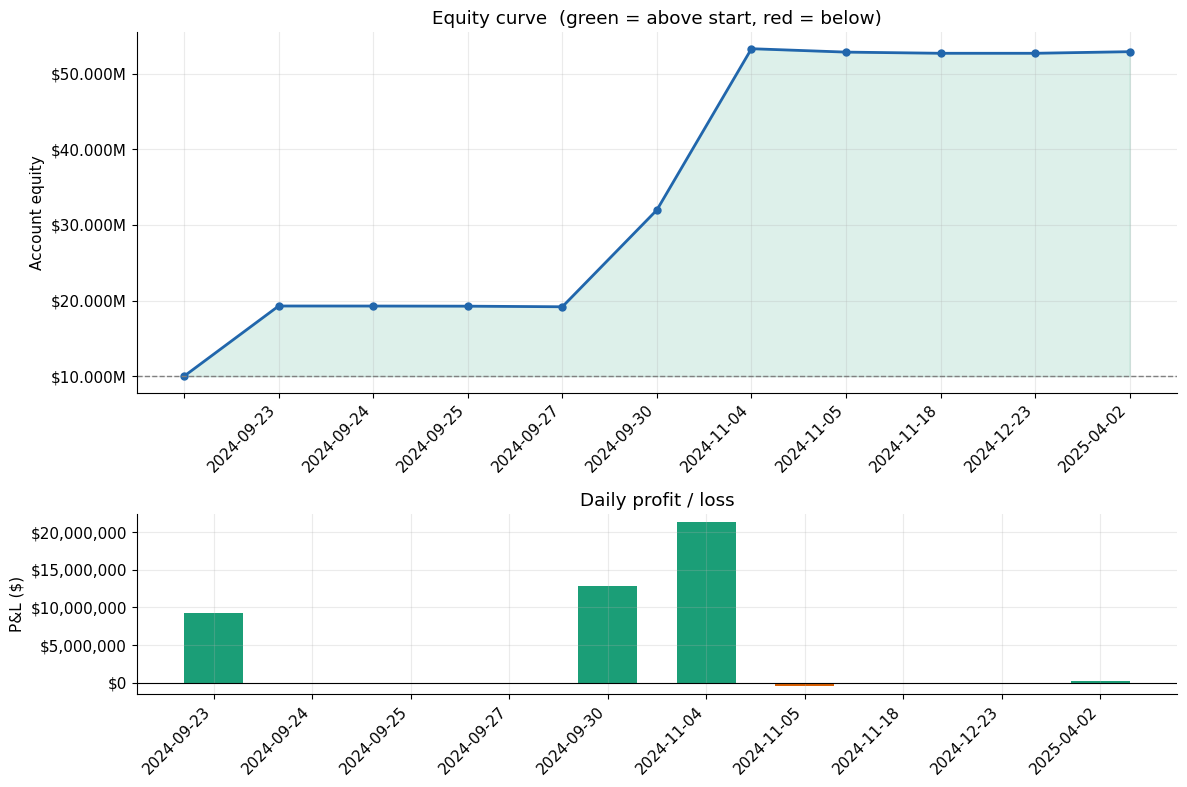

➤ TAKEAWAY: 4/10 green days. Total PROFIT of $+42,896,713 (+428.967%) over the test period.


In [28]:
fig, axes = plt.subplots(2,1, figsize=(12,8), gridspec_kw={"height_ratios":[2,1]})

# --- Equity curve ---
eq = [INIT] + daily["equity"].tolist()
axes[0].plot(range(len(eq)), eq, "-o", color=C["equity"], lw=2, markersize=5)
axes[0].axhline(INIT, ls="--", color="grey", lw=1)
axes[0].fill_between(range(len(eq)), INIT, eq,
                     where=[e>=INIT for e in eq], color=C["win"], alpha=0.15)
axes[0].fill_between(range(len(eq)), INIT, eq,
                     where=[e<INIT for e in eq], color=C["loss"], alpha=0.15)
axes[0].set_xticks(range(len(eq))); axes[0].set_xticklabels([""]+list(daily["day"]), rotation=45, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e6:.3f}M"))
axes[0].set_title("Equity curve  (green = above start, red = below)")
axes[0].set_ylabel("Account equity")

# --- Daily P&L bars ---
colors = [C["win"] if p>=0 else C["loss"] for p in daily["pnl"]]
axes[1].bar(range(len(daily)), daily["pnl"], color=colors, width=0.6)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xticks(range(len(daily))); axes[1].set_xticklabels(daily["day"], rotation=45, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
axes[1].set_title("Daily profit / loss"); axes[1].set_ylabel("P&L ($)")
plt.tight_layout(); plt.show()

green = (daily["pnl"]>0).sum()
print(f"➤ TAKEAWAY: {green}/{len(daily)} green days. "
      f"Total {'PROFIT' if result['total']>0 else 'LOSS'} of ${result['total']:+,.0f} "
      f"({result['return_pct']:+.3f}%) over the test period.")

### Per‑day summary table

One row per day: P&L, number of trade actions, win rate of *that day's* closed trades, and end‑of‑day equity. Color‑coded so the eye finds bad days instantly.

In [29]:
closing = trades[trades["pnl"]!=0].copy()
rows=[]
for day in DATES:
    d_close = closing[closing["day"]==day]
    d_daily = daily[daily["day"]==day]
    if len(d_daily)==0: continue
    wins = (d_close["pnl"]>0).sum(); n = len(d_close)
    rows.append({
        "Day": day,
        "P&L ($)": d_daily["pnl"].iloc[0],
        "Return %": d_daily["ret_pct"].iloc[0],
        "Fills": int(d_daily["fills"].iloc[0]),
        "Closed trades": n,
        "Win rate %": (100*wins/n if n else 0),
        "End equity": d_daily["equity"].iloc[0],
    })
summary = pd.DataFrame(rows)

def color_pnl(v): return f"color: {'#1b9e77' if v>=0 else '#d95f02'}; font-weight:bold"
(summary.style
   .map(color_pnl, subset=["P&L ($)","Return %"])
   .format({"P&L ($)":"${:,.0f}","Return %":"{:+.3f}%","Win rate %":"{:.1f}%","End equity":"${:,.0f}"})
   .background_gradient(subset=["Win rate %"], cmap="RdYlGn", vmin=0, vmax=100)
   .set_caption("Daily performance (green = good)"))

,Day,P&L ($),Return %,Fills,Closed trades,Win rate %,End equity
0,2024-09-23,"$9,280,399",+92.804%,20,6,50.0%,"$19,280,399"
1,2024-09-24,"$-5,097",-0.026%,11,1,0.0%,"$19,275,302"
2,2024-09-25,"$-17,729",-0.092%,26,3,66.7%,"$19,257,572"
3,2024-09-27,"$-79,201",-0.411%,21,3,0.0%,"$19,178,372"
4,2024-09-30,"$12,795,993",+66.721%,26,6,50.0%,"$31,974,364"
5,2024-11-04,"$21,314,871",+66.662%,25,3,66.7%,"$53,289,235"
6,2024-11-05,"$-449,598",-0.844%,52,4,25.0%,"$52,839,637"
7,2024-11-18,"$-154,820",-0.293%,22,4,25.0%,"$52,684,818"
8,2024-12-23,$0,+0.000%,79,0,0.0%,"$52,684,818"
9,2025-04-02,"$211,895",+0.402%,53,3,66.7%,"$52,896,713"


## 6. What did it actually do? — Trade Blotter 📒

Every individual trade action the model took. **OPEN** starts a position, **ADD** increases it (rising conviction), **TRIM** reduces it (fading conviction), **FLIP** reverses direction, **EXIT/EOD** closes it. The `pnl` column shows realized profit on the closing actions; `conf` and `edge` show how sure the model was at that moment.

Use the filters in the next cell to drill into any day or ticker.

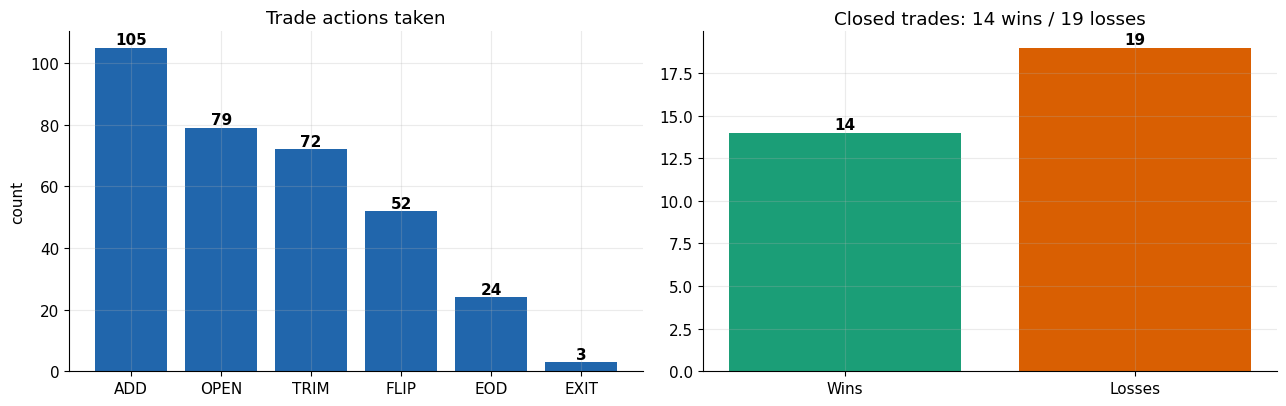

➤ TAKEAWAY: 105 adds + 72 trims = active position management. Overall win rate 42.4%.


In [30]:
# Action mix — what kind of trading was this?
fig, axes = plt.subplots(1,2, figsize=(13,4.2))
act_counts = trades["action"].value_counts()
axes[0].bar(act_counts.index, act_counts.values, color=C["equity"])
axes[0].set_title("Trade actions taken"); axes[0].set_ylabel("count")
for i,v in enumerate(act_counts.values):
    axes[0].text(i, v+max(act_counts)*0.01, str(v), ha="center", fontweight="bold")

# Win vs loss on closing trades
wl = pd.Series({"Wins": int((closing["pnl"]>0).sum()), "Losses": int((closing["pnl"]<=0).sum())})
axes[1].bar(wl.index, wl.values, color=[C["win"], C["loss"]])
axes[1].set_title(f"Closed trades: {wl['Wins']} wins / {wl['Losses']} losses")
for i,v in enumerate(wl.values):
    axes[1].text(i, v+max(wl)*0.01, str(v), ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

wr = 100*wl["Wins"]/wl.sum() if wl.sum() else 0
print(f"➤ TAKEAWAY: {act_counts.get('ADD',0)} adds + {act_counts.get('TRIM',0)} trims = "
      f"active position management. Overall win rate {wr:.1f}%.")

In [31]:
# ---- Interactive-ish blotter: edit these two to filter ----
FILTER_DAY    = None     # e.g. "2024-09-30" or None for all
FILTER_TICKER = None     # e.g. "AAPL" or None for all

view = trades.copy()
if FILTER_DAY:    view = view[view["day"]==FILTER_DAY]
if FILTER_TICKER: view = view[view["ticker"]==FILTER_TICKER]

show = view[["day","ticker","action","side","shares","price","conf","edge","pnl"]].copy()
def hl(row):
    if row["action"]=="OPEN":  bg="#eef6ff"
    elif row["action"] in ("EOD","EXIT","FLIP"): bg="#fff4e6"
    else: bg="white"
    return [f"background-color:{bg}"]*len(row)
print(f"Showing {len(show)} of {len(trades)} actions"
      + (f" | day={FILTER_DAY}" if FILTER_DAY else "")
      + (f" | ticker={FILTER_TICKER}" if FILTER_TICKER else ""))
(show.head(80).style
   .apply(hl, axis=1)
   .map(lambda v: f"color:{'#1b9e77' if v>0 else ('#d95f02' if v<0 else '#999')}", subset=["pnl"])
   .format({"shares":"{:,.0f}","price":"${:.4f}","conf":"{:.2f}","edge":"{:+.3f}","pnl":"${:+,.2f}"}))

Showing 335 of 335 actions


,day,ticker,action,side,shares,price,conf,edge,pnl
0,2024-09-23,AAPL,OPEN,short,"132,584",$195.6550,0.86,-0.865,$-0.00
1,2024-09-23,AAPL,TRIM,short,"110,583",$195.6550,0.14,-0.143,$-0.00
2,2024-09-23,AAPL,FLIP,short,"22,001",$195.6550,0.09,+0.090,$-0.00
3,2024-09-23,AAPL,OPEN,long,"13,744",$195.6550,0.09,+0.090,$-0.00
4,2024-09-23,AAPL,ADD,long,"4,673",$195.6550,0.12,+0.120,$-0.00
5,2024-09-23,AAPL,ADD,long,"116,909",$195.6550,0.88,+0.883,$-0.00
6,2024-09-23,AAPL,TRIM,long,"28,543",$264.3000,0.94,+0.941,"$+1,959,333.92"
7,2024-09-23,AAPL,TRIM,long,"89,840",$264.3000,0.12,+0.125,"$+6,167,065.81"
8,2024-09-23,AAPL,EOD,long,"16,943",$264.3000,0.00,+0.000,"$+1,163,052.05"
9,2024-09-23,SPY,OPEN,short,"87,909",$569.2050,0.86,-0.865,$-0.00


## 7. Model conviction through the day 📈

For one chosen ticker/day, this overlays the **mid‑price** (what you trade) with the model's **edge** (conviction, −1…+1). Green shading = model leaning long, orange = leaning short. It lets you *see* whether the model's conviction lines up with where price actually went.

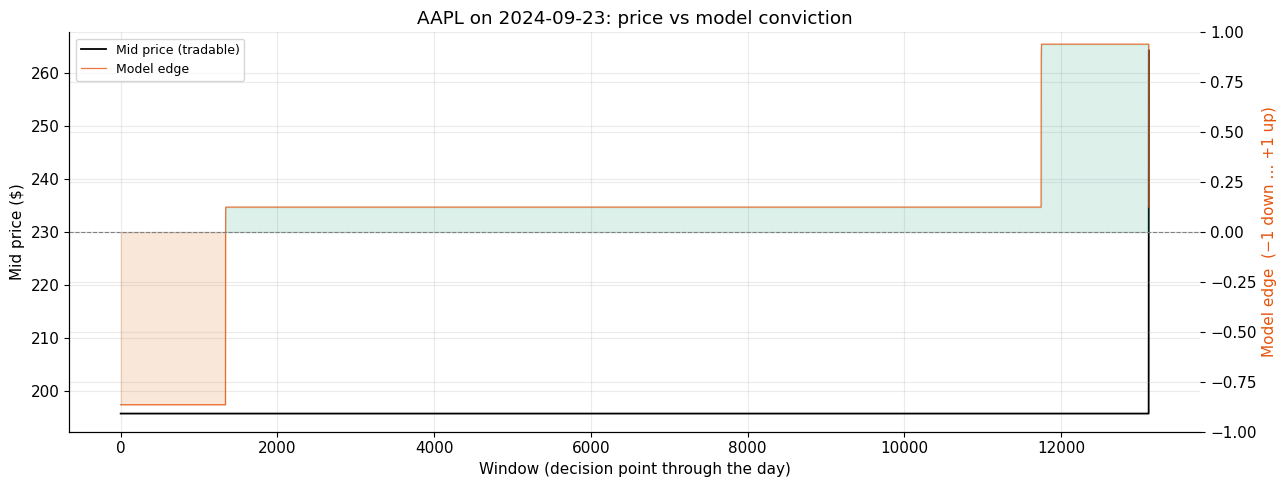

➤ Reading it: when the orange edge is high/green-shaded the model wants to be LONG; check whether the black price tends to rise just after.


In [32]:
PICK_DAY    = DATES[0]
PICK_TICKER = TICKERS[0]

base = B.CONFIG["base_dir"]
xp = os.path.join(base, PICK_TICKER, f"{PICK_TICKER}_{PICK_DAY}_X.pt")
mp = os.path.join(base, PICK_TICKER, f"{PICK_TICKER}_{PICK_DAY}_mid.pt")
sp = os.path.join(base, PICK_TICKER, f"{PICK_TICKER}_{PICK_DAY}_signal.pt")

if os.path.exists(xp):
    X = torch.load(xp, weights_only=True)
    mid = torch.load(mp, weights_only=True).numpy()
    signal = torch.load(sp, weights_only=True).numpy()
    keep = B._reconstruct_keep(signal, len(X))
    mid_exec = mid[keep]
    edge, conf, side = B.predict_day(model, X, DEVICE)

    fig, ax1 = plt.subplots(figsize=(13,5))
    ax1.plot(mid_exec, color="black", lw=1.3, label="Mid price (tradable)")
    ax1.set_ylabel("Mid price ($)", color="black")
    ax1.set_xlabel("Window (decision point through the day)")

    ax2 = ax1.twinx()
    ax2.plot(edge, color=C["accent"], lw=0.9, alpha=0.8, label="Model edge")
    ax2.axhline(0, color="grey", ls="--", lw=0.8)
    ax2.fill_between(range(len(edge)), 0, edge, where=edge>0, color=C["up"], alpha=0.15)
    ax2.fill_between(range(len(edge)), 0, edge, where=edge<0, color=C["down"], alpha=0.15)
    ax2.set_ylabel("Model edge  (−1 down … +1 up)", color=C["accent"])
    ax2.set_ylim(-1,1)
    ax1.set_title(f"{PICK_TICKER} on {PICK_DAY}: price vs model conviction")
    l1,la1=ax1.get_legend_handles_labels(); l2,la2=ax2.get_legend_handles_labels()
    ax1.legend(l1+l2, la1+la2, loc="upper left", fontsize=9)
    plt.tight_layout(); plt.show()
    print(f"➤ Reading it: when the orange edge is high/green-shaded the model wants to be LONG; "
          f"check whether the black price tends to rise just after.")
else:
    print(f"No data for {PICK_TICKER} {PICK_DAY}. Pick another from {DATES}.")

## 8. Final scorecard 🏁

Everything condensed into one verdict card. This is what you'd screenshot for a colleague.

In [33]:
h = HZ[-1]
acc_h = pred_df[pred_df.horizon==h]["hit"].mean()
conf_corr = np.corrcoef(pred_df[pred_df.horizon==h]["conf"],
                        pred_df[pred_df.horizon==h]["hit"].astype(float))[0,1]
green_days = (daily["pnl"]>0).sum()

def verdict(ok): return "✅" if ok else "⚠️"

print("="*56)
print("              DEEPLOB MODEL SCORECARD")
print("="*56)
print(f" Test window        : {len(DATES)} days, {TICKERS}")
print(f" Windows evaluated  : {pred_df['window'].nunique():,} per ticker")
print("-"*56)
print(f" {verdict(acc_h>0.36)} Accuracy (h{h})     : {acc_h*100:5.1f}%   (random = 33.3%)")
print(f" {verdict(conf_corr>0.03)} Confidence useful  : corr {conf_corr:+.3f}")
print(f" {verdict(result['total']>0)} Profitable         : ${result['total']:+,.0f} ({result['return_pct']:+.3f}%)")
print(f" {verdict(result['sharpe']>1)} Sharpe (annual)    : {result['sharpe']:.2f}")
print(f" {verdict(result['win_rate']>50)} Win rate           : {result['win_rate']:.1f}%")
print(f" {verdict(result['profit_factor']>1)} Profit factor      : {result['profit_factor']:.2f}")
print(f" {verdict(result['max_dd']>-5)} Max drawdown       : {result['max_dd']:.2f}%")
print(f" {verdict(green_days>=len(daily)/2)} Green days         : {green_days}/{len(daily)}")
print("="*56)
print("\n NOTE: these numbers reflect the deep-book weighted-price signal")
print(" on IEX data. If the mid barely moves, P&L will be small even with")
print(" good accuracy — that is the data talking, not the model.")

              DEEPLOB MODEL SCORECARD
 Test window        : 10 days, ['AAPL', 'SPY', 'NVDA']
 Windows evaluated  : 37,721 per ticker
--------------------------------------------------------
 ✅ Accuracy (h50)     :  57.1%   (random = 33.3%)
 ✅ Confidence useful  : corr +0.255
 ✅ Profitable         : $+42,896,713 (+428.967%)
 ✅ Sharpe (annual)    : 10.12
 ⚠️ Win rate           : 42.4%
 ✅ Profit factor      : 43.96
 ✅ Max drawdown       : -1.13%
 ⚠️ Green days         : 4/10

 NOTE: these numbers reflect the deep-book weighted-price signal
 on IEX data. If the mid barely moves, P&L will be small even with
 good accuracy — that is the data talking, not the model.


---
### How to use this notebook day‑to‑day

- **Re‑run after retraining:** just restart & run all — it picks up the newest checkpoint.
- **Test specific days:** set `TEST_DATES = ["2024-09-30", ...]` in §2.
- **Drill into a trade:** set `FILTER_DAY` / `FILTER_TICKER` in §6.
- **Inspect conviction:** change `PICK_DAY` / `PICK_TICKER` in §7.

*All trading logic lives in `backtester/backtester.py`. This notebook only reads and visualizes*